# UMAP

Check out this website to get a better understanding for UMAP:

https://pair-code.github.io/understanding-umap/





    conda install -c conda-forge umap-learn

or 


    pip install umap-learn

Additional installations into your environment are needed:

    pip install pandas matplotlib datashader bokeh holoviews scikit-image colorcet
        
might be also necessary:

    conda install dask
    pip install datamapplot

To install the widgets try:

    pip install ipympl
    or 
    conda install -c conda-forge ipympl

first try if the widgets work now. Restart might be necsassary. 

Try this in the terminal if it still does not work:

    jupyter nbextension enable --py --sys-prefix ipympl


## Load modules

In [13]:
import numpy as np
import pandas as pd
import math

import glob
import os

import matplotlib.pylab as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from obspy import read, UTCDateTime

from scipy.fftpack import fft, fftfreq, next_fast_len

%load_ext autoreload
%autoreload 2
%matplotlib inline 
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
def calculate_distance(point1, point2):
    # Unpack points
    x1, y1 = point1
    x2, y2 = point2
    
    # Calculate the distance
    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return distance

# Function to calculate Euclidean distance from point (px, py) to (x, y)
def calculate_distance_df(row, px, py):
    return np.sqrt((row['lon'] - px) ** 2 + (row['lat'] - py) ** 2)

def calculate_distance(row):
    dlon = row['ev_lon'] - row['lon']
    dlat = row['ev_lat'] - row['lat']
    distance = np.sqrt(dlon**2 + dlat**2)
    return distance

def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return freq, spec 




In [15]:
# not well picked
path_to_strikewise_folder = "strike_wise"

picks_file_name = "PICKS_LAST_YEAR/*.txt"

# for saving some outputs
save_path = os.path.dirname(picks_file_name)

# UMAP

In [16]:
from bokeh.io import output_notebook
from bokeh.plotting import figure, show, ColumnDataSource
from bokeh.models import HoverTool
import matplotlib as mpl

import umap.plot

In [17]:
df_picks_all = pd.read_csv(os.path.join(save_path, f"combined_strikes_with_mean_std.csv"))
print("Number of all picks collected:", len(df_picks_all))
print("Number of non-nan values in:", df_picks_all['group'].value_counts().sum())
df_picks_all.head()


Number of all picks collected: 1403
Number of non-nan values in: 1398


,Unnamed: 0,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,dt,group,mean,std
0,0,2024-06-06T17:38:02.234260Z,1,1,SH,39175,P,3.0,-3.0,2.0,-3.0,0,0,1.0,0.00000,0.0,0.011059,0.006884
1,1,2024-06-06T17:38:02.240110Z,1,1,SH,33115,P,3.0,-3.0,1.0,-3.0,0,0,2.0,0.00585,0.0,0.011059,0.006884
2,2,2024-06-06T17:38:02.244100Z,1,1,SH,31498,P,3.0,-3.0,0.0,-3.0,0,0,3.0,0.00984,0.0,0.011059,0.006884
3,3,2024-06-06T17:38:02.247960Z,1,1,SH,31640,P,3.0,-3.0,-1.0,-3.0,0,0,4.0,0.01370,0.0,0.011059,0.006884
4,4,2024-06-06T17:38:02.250230Z,1,1,SH,33105,P,3.0,-3.0,-2.0,-3.0,0,0,5.0,0.01597,0.0,0.011059,0.006884


Parameters to look at different clusters depending on experiments and station location. 

In [18]:
# parameters 
phase = 'S'  # or 'P', '?' etc
min_exp = -1  # put to -1 and 
max_exp = 99 # put to 99 to include all picks

# select station distances to source 

min_dist_2_source = 0  # max meters away from source; put to 0 and 99 to include all picksto include all picks 
max_dist_2_source = 99  # max meters away from source 

2024-06-06T17:38:02.242110Z
2024-06-06T17:38:02.242110Z
0.0
2024-06-06T17:38:02.967950Z
2024-06-06T17:38:02.967950Z
0.0
2024-06-06T17:38:03.688260Z
2024-06-06T17:38:03.688260Z
0.0
2024-06-06T17:38:04.405820Z
2024-06-06T17:38:04.405820Z
0.0
2024-06-06T17:38:05.079310Z
2024-06-06T17:38:05.079310Z
0.0
2024-06-06T17:38:02.247960Z
2024-06-06T17:38:02.247960Z
0.00585
2024-06-06T17:38:02.974020Z
2024-06-06T17:38:02.974020Z
0.00607
2024-06-06T17:38:03.694960Z
2024-06-06T17:38:03.694960Z
0.0067
2024-06-06T17:38:04.412700Z
2024-06-06T17:38:04.412700Z
0.00688
2024-06-06T17:38:05.085470Z
2024-06-06T17:38:05.085470Z
0.00616
2024-06-06T17:38:02.251560Z
2024-06-06T17:38:02.251560Z
0.00945
2024-06-06T17:38:02.977690Z
2024-06-06T17:38:02.977690Z
0.00974
2024-06-06T17:38:03.697780Z
2024-06-06T17:38:03.697780Z
0.00952
2024-06-06T17:38:04.416080Z
2024-06-06T17:38:04.416080Z
0.01026
2024-06-06T17:38:05.089050Z
2024-06-06T17:38:05.089050Z
0.00974
2024-06-06T17:38:02.255680Z
2024-06-06T17:38:02.255680Z
0.013

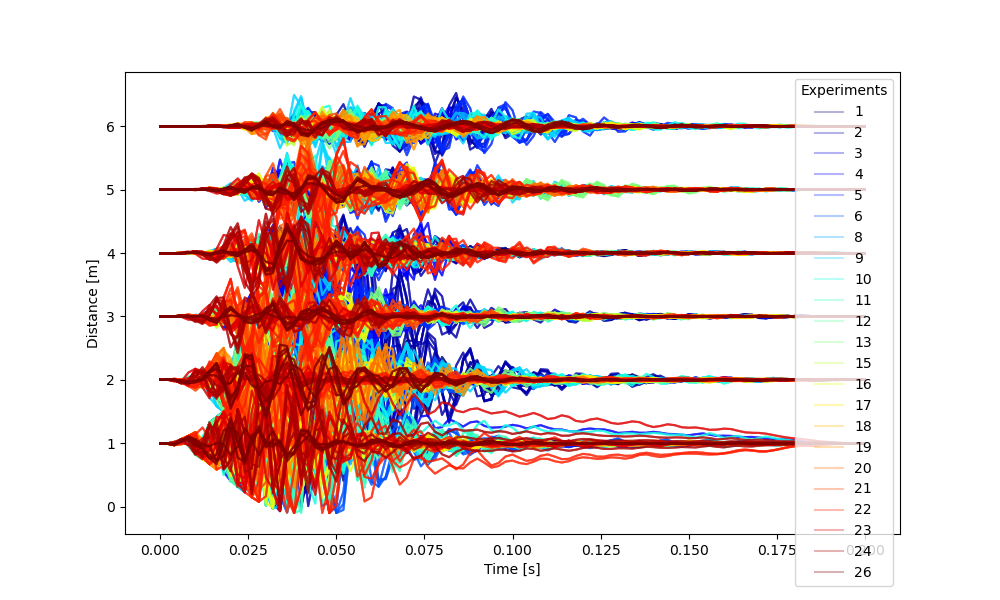

In [10]:
# Ensure 'group' column contains only numeric values and handle NaNs
df_picks_all['group'] = pd.to_numeric(df_picks_all['group'], errors='coerce')

selected_picks = df_picks_all[(df_picks_all['phase'] == phase) & 
                              (df_picks_all['experiment'] >= min_exp) & 
                              (df_picks_all['experiment'] <= max_exp) & 
                              (df_picks_all['distance_to_source'] <= max_dist_2_source) & 
                              (df_picks_all['distance_to_source'] >= min_dist_2_source)] 


# Create a colormap with distinct colors
cmap = plt.get_cmap('jet')  # 'tab10' has 10 distinct colors
norm = mcolors.Normalize(vmin=min(selected_picks['experiment'].unique()), vmax=max(selected_picks['experiment'].unique()) - 1)


# Dictionary to store legend handles
legend_handles = {}

X = None
desc_inst = []
desc_dist = []
desc_x = []
desc_y = []
desc_group = []


plt.figure(figsize=(10, 6))

for j, sta_row in selected_picks.iterrows():
    if sta_row['phase'] != phase:
        continue
    if (sta_row['experiment'] < min_exp):
        continue
    if (sta_row['experiment'] > max_exp):
        continue
    number_hammer_strike = sta_row['experiment']
    station = sta_row['sta']
    st = read(glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/*{station}*.mseed"))[0])
    # print(st)
    # XXX filter 2-150 Hz XXX 2-50/70 XXX 70-150 XXX 
    # broadband: frequency vs distance 

    selected_sta = selected_picks[(selected_picks['sta'] == station) & (selected_picks['phase'] == phase) & (selected_picks['experiment'] == number_hammer_strike)].sort_values('datetime')

    for i, row in selected_sta.iterrows():

        st_sliced = st.copy()
        print(row['datetime'])
        print(UTCDateTime(row['datetime']))   
        print(row['dt'])
        st_sliced.trim(UTCDateTime(row['datetime'])-row['dt'], UTCDateTime(row['datetime'])+0.2-row['dt'])
        st_sliced[0].taper(0.2, type='cosine')

        if X is None:
            X =  st_sliced[0].data
        else:
            X = np.vstack([X,  st_sliced[0].data])
        desc_inst.append(row['sta'])
        desc_dist.append(row['distance_to_source'])
        desc_x.append(row['lon'])
        desc_y.append(row['lat'])
        desc_group.append(row['group'])
        
        time_axis = st_sliced[0].times()
        try:
            line, = plt.plot(time_axis, st_sliced[0].data+row['distance_to_source'], color=cmap(norm(row['experiment'])), alpha=0.3)
        except Exception as e:
            print(e)
            continue

        # Add legend handle if not already added
        if row['experiment'] not in legend_handles:
            legend_handles[row['experiment']] = line

plt.xlabel('Time [s]')
plt.ylabel('Distance [m]')
# Create legend
plt.legend(legend_handles.values(), legend_handles.keys(), title='Experiments', loc='upper right')

plt.show()

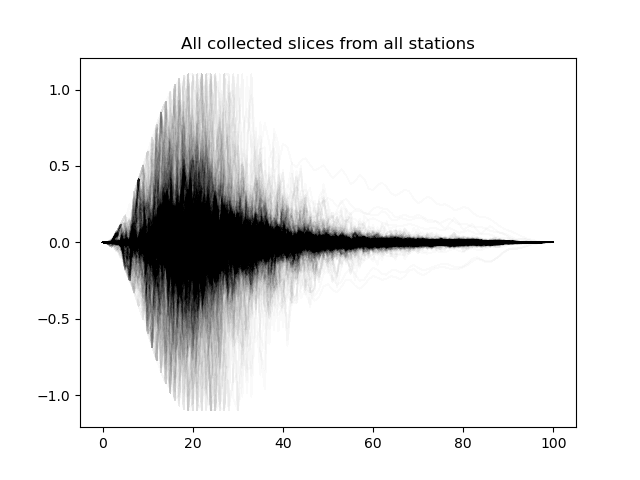

In [11]:
plt.figure()
for x in X:
    plt.plot(x, color='k', alpha=0.005)
plt.title('All collected slices from all stations')
plt.show()

In [19]:
X_norm = np.linalg.norm(X, axis=-1)[:, np.newaxis]
yy, zz = np.where(X_norm == 0)
for y, z in zip(yy, zz):
    X_norm[y][z] = X_norm[y-1][z]

mapper = umap.UMAP(
n_neighbors=20,  # It determines the number of neighboring points used in local approximations
n_components=10, # This parameter determines the number of dimensions of the space to which the data will be reduced.
metric="cosine",
random_state=1364,
low_memory=False,
min_dist=0.8, # This parameter controls how tightly UMAP packs points together
)

mapper.verbose = True
mapper = mapper.fit(X / X_norm)
dim_red_X = mapper.embedding_

source_train = ColumnDataSource(data=dict(x = dim_red_X[:,0],y = dim_red_X[:,1],
            colors=["#%02x%02x%02x" % (int(r), int(g), int(b)) for r, g, b, _ in 255*mpl.cm.jet(mpl.colors.Normalize()(desc_y))],  
            # desc_soil=desc_soil,
            desc_dist=desc_dist,
            desc_x=desc_x,desc_y=desc_y))

hover_dim = HoverTool( 
                      tooltips=[
                        #   ("Soil", "@desc_soil"), 
                                ("X", "@desc_x"), ("Y", "@desc_y"), ("Distance", "@desc_dist"), ]
                     )


tools_dim = [hover_dim, 'pan', 'wheel_zoom', 'reset', "box_zoom"]
plot_dim = figure(width=800, height=800, tools=tools_dim)

plot_dim.scatter('x', 'y', 
                 size=5, 
                 fill_color='colors', 
                 alpha=0.4, 
                 line_width=0.0, 
                 source=source_train, 
                 name="train")

show(plot_dim)

/Users/tnm/anaconda3/envs/mth3035/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.8, n_components=10, n_jobs=1, n_neighbors=20, random_state=1364, verbose=True)
Thu Oct 23 09:12:49 2025 Construct fuzzy simplicial set
Thu Oct 23 09:12:52 2025 Finding Nearest Neighbors
Thu Oct 23 09:12:52 2025 Finished Nearest Neighbor Search
Thu Oct 23 09:12:52 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Oct 23 09:12:58 2025 Finished embedding
